In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
df = pd.read_csv('final_chess.csv',index_col =[0])
df

C:\Users\miche\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,?,?,*,????.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",2804.0,2666.0
1,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
2,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
3,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
4,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
...,...,...,...,...,...,...,...
3691276,"Andersson, S","Andersson, Ka",1/2-1/2,2010.07.07,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.0,2392.0
3691277,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2392.0
3691278,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2211.0
3691279,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.07.07,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",NaN,2224.0


Cleaning date

In [4]:
a = df['DATE'].to_list()

In [5]:
for i in range(len(a)):
    a[i] = a[i][:4]
    
    if a[i][0] == '0' or a[i][0] == '?':
        a[i] = np.nan
    
    try:
        a[i] = int(a[i])
    except:
        continue
        

In [7]:
df['DATE'] = a

We want to get the mean of the elo from 2000 to 2009 of 4 great chess players

For each player and each year the mean of the elo appearing on w_elo column and b_elo column will be computed 

The missing values are imputed with the mean of the elo in that respective year

In [14]:
magnus = df[(df['WHITE'] == 'Carlsen, Magnus') | (df['BLACK'] == 'Carlsen, Magnus')]

In [15]:
kasp = df[(df['WHITE'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, G..') | 
   (df['BLACK'] == 'Kasparov, G..') | (df['WHITE'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, Garry')]

In [17]:
naka = df[(df['WHITE'] == 'Nakamura, Hikaru') | (df['BLACK'] == 'Nakamura, Hikaru')]

In [44]:
def find_mean(w,b):
    return (w['W_ELO'].sum() + b['B_ELO'].sum())/(len(w)+len(b))

In [70]:
mag_means = []
kasp_means = []
naka_means = []

In [71]:
w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2000)]

In [72]:
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2000)]

In [73]:
b_m

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
2124521,"Bartels, Holger","Carlsen, Magnus",1/2-1/2,2000.0,"['e4', 'e5', 'Nf3', 'Nc6', 'Bc4', 'Nf6', 'Ng5'...",NaN,2145.0


In [74]:
mag_2000 = w_m['W_ELO'].mean()
mag_means.append(mag_2000)
mag_2000

2244.0

In [75]:
w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2001)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2001)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2001= find_mean(w_m,b_m)
mag_means.append(mag_2001)
#mag_2001

w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2002)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2002)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2002= find_mean(w_m,b_m)
mag_means.append(mag_2002)


w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2003)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2003)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2003= find_mean(w_m,b_m)
mag_means.append(mag_2003)

w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2004)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2004)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2004= find_mean(w_m,b_m)
mag_means.append(mag_2004)

w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2005)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2005)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2005= find_mean(w_m,b_m)
mag_means.append(mag_2005)

w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2006)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2006)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2006= find_mean(w_m,b_m)
mag_means.append(mag_2006)



w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2007)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2007)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2007= find_mean(w_m,b_m)
mag_means.append(mag_2007)

w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2008)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2008)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2008= find_mean(w_m,b_m)
mag_means.append(mag_2008)

w_m = magnus[(magnus['WHITE'] == 'Carlsen, Magnus') & (magnus['DATE'] == 2009)]
b_m = magnus[(magnus['BLACK'] == 'Carlsen, Magnus') & (magnus['DATE'] == 200)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
mag_2009= find_mean(w_m,b_m)
mag_means.append(mag_2009)

C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anac

In [76]:
w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2000)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2000)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2000= find_mean(w_m,b_m)
naka_means.append(naka_2000)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2001)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2001)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2001= find_mean(w_m,b_m)
naka_means.append(naka_2001)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2002)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2002)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2002= find_mean(w_m,b_m)
naka_means.append(naka_2002)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2003)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2003)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2003= find_mean(w_m,b_m)
naka_means.append(naka_2003)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2004)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2004)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2004= find_mean(w_m,b_m)
naka_means.append(naka_2004)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2005)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2005)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2005= find_mean(w_m,b_m)
naka_means.append(naka_2005)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2006)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2006)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2006= find_mean(w_m,b_m)
naka_means.append(naka_2006)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2007)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2007)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2007= find_mean(w_m,b_m)
naka_means.append(naka_2007)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2008)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2008)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2008= find_mean(w_m,b_m)
naka_means.append(naka_2008)

w_m = naka[(naka['WHITE'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2009)]
b_m = naka[(naka['BLACK'] == 'Nakamura, Hikaru') & (naka['DATE'] == 2009)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
naka_2009= find_mean(w_m,b_m)
naka_means.append(naka_2009)

C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anac

In [116]:
w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2000)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2000)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2000= find_mean(w_m,b_m)
kasp_means.append(kasp_2000)


w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2001)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2001)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2001= find_mean(w_m,b_m)
kasp_means.append(kasp_2001)


w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2002)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2002)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2002= find_mean(w_m,b_m)
kasp_means.append(kasp_2002)

w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2003)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2003)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2003= find_mean(w_m,b_m)
kasp_means.append(kasp_2003)


w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2004)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2004)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2004= find_mean(w_m,b_m)
kasp_means.append(kasp_2004)

w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2005)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2005)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2005= find_mean(w_m,b_m)
kasp_means.append(kasp_2005)


w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2006)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2006)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2006= find_mean(w_m,b_m)
kasp_means.append(kasp_2006)

w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2007)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2007)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2007= find_mean(w_m,b_m)
kasp_means.append(kasp_2007)

w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2008)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2008)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2008= find_mean(w_m,b_m)
kasp_means.append(kasp_2008)


w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2009)]

b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..')) 
           & (kasp['DATE'] == 2009)]

w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
kasp_2009= find_mean(w_m,b_m)
kasp_means.append(kasp_2009)

<ipython-input-116-1b5420c9e006>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE'] == 'Kasparov, G..'))
<ipython-input-116-1b5420c9e006>:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  b_m = kasp[((kasp['BLACK'] == 'Kasparov, G') | (df['BLACK'] == 'Kasparov, Garry') | (df['BLACK'] == 'Kasparov, G..'))
C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
<ipython-input-116-1b5420c9e006>:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  w_m = kasp[((kasp['WHITE'] == 'Kasparov, G') | (df['WHITE'] == 'Kasparov, Garry') | (df['WHITE

In [148]:
anand = df[(df['WHITE'] == 'Anand, Viswanathan') | (df['BLACK'] == 'Anand, Viswanathan')]

In [150]:
anand_means = []

In [151]:
w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2000)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2000)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2000= find_mean(w_m,b_m)
anand_means.append(anand_2000)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2001)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2001)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2001= find_mean(w_m,b_m)
anand_means.append(anand_2001)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2002)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2002)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2002= find_mean(w_m,b_m)
anand_means.append(anand_2002)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2003)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2003)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2003= find_mean(w_m,b_m)
anand_means.append(anand_2003)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2004)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2004)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2004= find_mean(w_m,b_m)
anand_means.append(anand_2004)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2005)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2005)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2005= find_mean(w_m,b_m)
anand_means.append(anand_2005)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2006)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2006)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2006= find_mean(w_m,b_m)
anand_means.append(anand_2006)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2007)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2007)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2007= find_mean(w_m,b_m)
anand_means.append(anand_2007)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2008)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2008)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2008= find_mean(w_m,b_m)
anand_means.append(anand_2008)

w_m = anand[(anand['WHITE'] == 'Anand, Viswanathan') & (anand['DATE'] == 2009)]
b_m = anand[(anand['BLACK'] == 'Anand, Viswanathan') & (anand['DATE'] == 2009)]
w_m['W_ELO'].fillna(value = w_m['W_ELO'].mean(),inplace = True)
b_m['B_ELO'].fillna(value = b_m['B_ELO'].mean(),inplace = True)
anand_2009= find_mean(w_m,b_m)
anand_means.append(anand_2009)

C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(
C:\Users\miche\anac

In [152]:
anand_means

[2535.1736871823828,
 2553.980439404678,
 2558.6201325600664,
 2558.32198019802,
 2541.8947368421054,
 2565.5928143712576,
 2589.6605664488015,
 2574.536082474227,
 2551.2327586206898,
 2571.839285714286]

Fix missing values in kasparov means

In [118]:
len(kasp_means)

10

In [117]:
kasp_means

[2572.4416658589384,
 2587.7703955948414,
 2557.5809911242604,
 2574.978021978022,
 2540.23725678268,
 2600.1463414634145,
 2615.65,
 nan,
 2280.0,
 2617.6339743589747]

In [124]:
to_sub = (sum(kasp_means[:7])+sum(kasp_means[8:])) / (len(kasp_means)-1)
to_sub

2549.6042941290148

In [126]:
kasp_means[7] = to_sub

In [127]:
kasp_means

[2572.4416658589384,
 2587.7703955948414,
 2557.5809911242604,
 2574.978021978022,
 2540.23725678268,
 2600.1463414634145,
 2615.65,
 2549.6042941290148,
 2280.0,
 2617.6339743589747]

In [128]:
naka_means

[2294.5868421052633,
 2369.855072463768,
 2401.317627494457,
 2464.818565400844,
 2468.5929507844403,
 2501.058748403576,
 2513.9777777777776,
 2502.842105263158,
 2528.4,
 2515.2102272727275]

In [129]:
mag_means

[2244.0,
 2172.4933370094664,
 2254.3483316481293,
 2391.6541968911915,
 2418.172727272727,
 2455.962001967536,
 2485.692000981475,
 2526.250635451505,
 2564.2285714285713,
 2338.6837606837607]

In [130]:
years = [2000,2001,2002,2003,2004,2005,2006,2007,2008,2009]

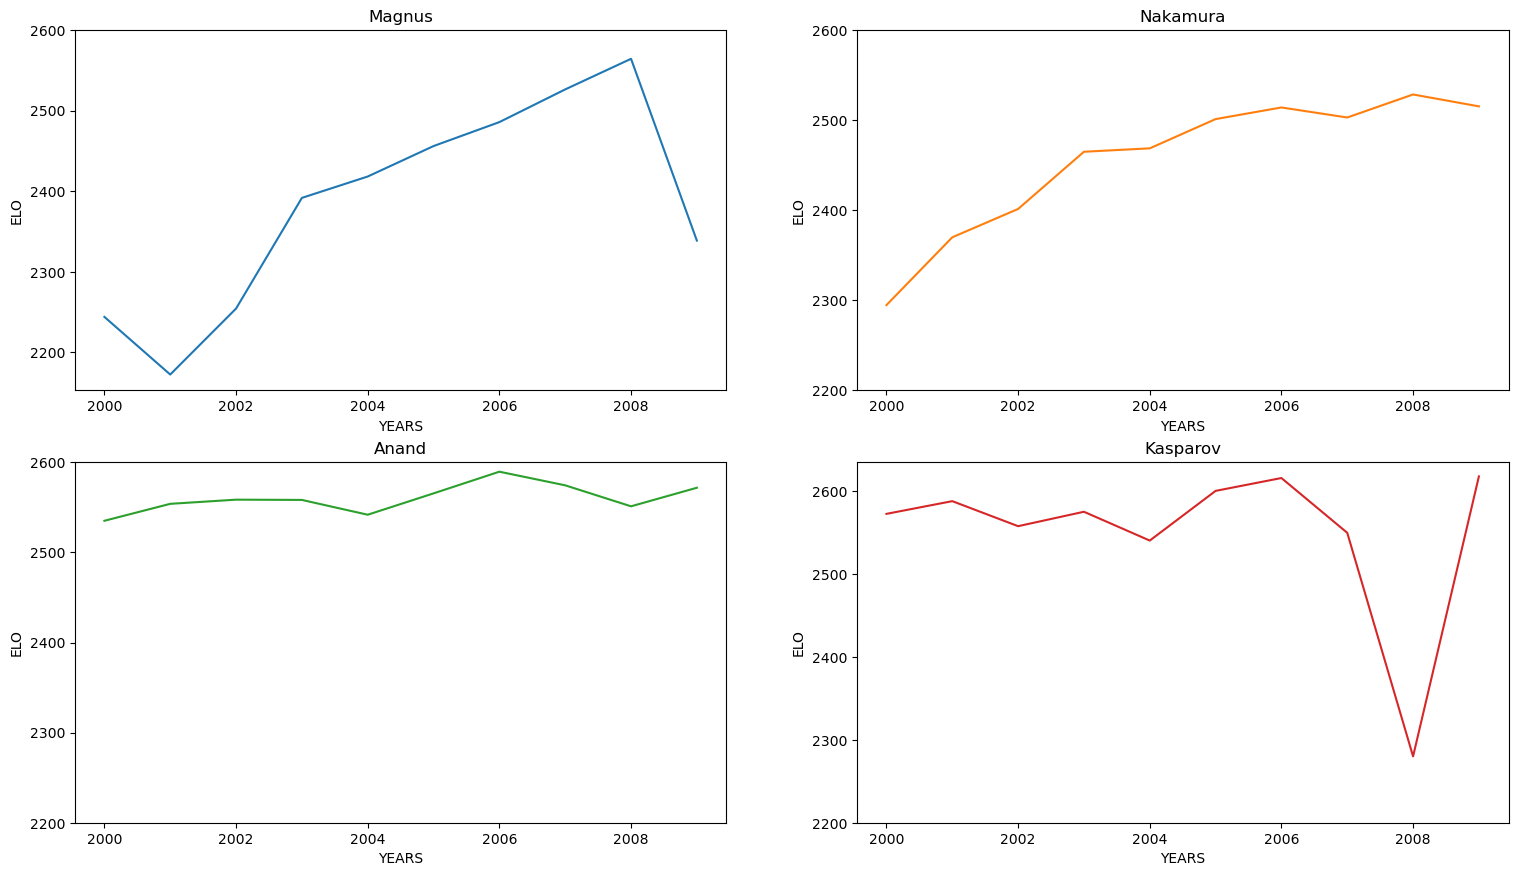

In [157]:
fig, axs = plt.subplots(2,2)
fig.set_size_inches(18.5, 10.5)
fig.set_dpi(100)
axs[0, 0].plot(years, mag_means)
axs[0, 0].set_title('Magnus')
axs[0, 0].set_yticks([2200,2300,2400,2500,2600])
axs[0, 1].plot(years, naka_means, 'tab:orange')
axs[0, 1].set_title('Nakamura')
axs[0, 1].set_yticks([2200,2300,2400,2500,2600])
axs[1, 0].plot(years, anand_means, 'tab:green')
axs[1, 0].set_title('Anand')
axs[1, 0].set_yticks([2200,2300,2400,2500,2600])
axs[1, 1].plot(years,kasp_means, 'tab:red')
axs[1, 1].set_title('Kasparov')
axs[1, 1].set_yticks([2200,2300,2400,2500,2600])

for ax in axs.flat:
    ax.set(xlabel='YEARS', ylabel='ELO')
    
fig.savefig('top_players.png', dpi=100)
plt.show()